In [1]:
import pandas as pd
import geopandas as gpd

import calplot
import seaborn as sns
import matplotlib.pyplot as plt

from typing import Literal, Optional

import os
import sys

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils.configure_scienceplots import configure_scienceplots  # noqa: E402
from utils.load_data import load_processed_original_data, resample_data  # noqa: E402
from utils.constants import FIGURES_DIR, RAW_DATA_DIR  # noqa: E402

HEATMAPS_TIMELINES_FIGURES_DIR = FIGURES_DIR / "heatmaps" / "timelines"
HEATMAPS_TIMELINES_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LOCALIDAD_SHAPEFILE = RAW_DATA_DIR / "poligonos-localidades.zip"

In [2]:
configure_scienceplots()

In [3]:
# Load the processed original data as a GeoDataFrame
original_gdf = load_processed_original_data(as_geopandas=True, parse_dates=True)

localities_cols = list(original_gdf["LOCALIDAD"].unique())

# Load the locality shapefile
localities = gpd.read_file(LOCALIDAD_SHAPEFILE).to_crs("EPSG:4326")
localities["centroid"] = localities["geometry"].centroid.to_crs("EPSG:4326")
localities = (
    localities[localities["Nombre_de_l"].isin(localities_cols)]
    .drop(columns=["Acto_admini", "Area_de_la_", "Identificad"])
    .rename(columns={"Nombre_de_l": "LOCALIDAD"})
)

localities_centroids = (
    localities[["LOCALIDAD", "centroid"]].set_index("LOCALIDAD").to_dict()["centroid"]
)

localities_centroids = dict(
    map(
        lambda item: (item[0], (item[1].xy[0][0], item[1].xy[1][0])),
        localities_centroids.items(),
    )
)

localities_centroids

/tmp/ipykernel_346886/298046984.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  localities["centroid"] = localities["geometry"].centroid.to_crs("EPSG:4326")


{'SANTA FE': (-74.03621758151407, 4.593972728724646),
 'BARRIOS UNIDOS': (-74.07355160510069, 4.669566933458008),
 'FONTIBON': (-74.14015130074621, 4.67818292595219),
 'ENGATIVA': (-74.11318770329797, 4.701125563272906),
 'CANDELARIA': (-74.07207079532778, 4.596605075136357),
 'TUNJUELITO': (-74.13598945142, 4.574841398493438),
 'PUENTE ARANDA': (-74.11158023352897, 4.616245470318943),
 'RAFAEL URIBE URIBE': (-74.1133631829354, 4.56647690086027),
 'KENNEDY': (-74.1526676238341, 4.630347351356093),
 'USME': (-74.14280649581963, 4.390025128368835),
 'LOS MARTIRES': (-74.08794786812676, 4.607155934954452),
 'CIUDAD BOLIVAR': (-74.1619589044063, 4.482460265935735),
 'SUBA': (-74.07584527554698, 4.763208121309923),
 'BOSA': (-74.19438893446517, 4.621779959835892),
 'ANTONIO NARIÑO': (-74.1028424006145, 4.588770674796082),
 'CHAPINERO': (-74.03688302787356, 4.644982720078631),
 'SAN CRISTOBAL': (-74.0660725605067, 4.548749008988842),
 'TEUSAQUILLO': (-74.08576901958142, 4.641173586592106),
 

## For all localities

In [169]:
resample_month_df = resample_data(freq="1ME", multi_index=True)
resample_month_df

TOTAL_ACCIDENTES   GRAVEDAD                          CLASE  \
                                  SOLO DANOS CON HERIDOS CON MUERTOS CHOQUE   
FECHA_OCURRENCIA                                                              
2007-01-31                   2633       1506        1093          34   1965   
2007-02-28                   3034       1760        1230          44   2291   
2007-03-31                   3253       1878        1332          43   2436   
2007-04-30                   2900       1661        1205          34   2152   
2007-05-31                   3085       1823        1219          43   2357   
...                           ...        ...         ...         ...    ...   
2017-05-31                   3116       2187         879          50   2723   
2017-06-30                   2378       1669         662          47   2082   
2017-07-31                   2466       1703         721          42   2150   
2017-08-31                   2635       1791         795          49   2266   
2017-09-30                   2230       1481         714          35   1925   

                                                                        ...  \
                 ATROPELLO OTRO VOLCAMIENTO CAIDA DE OCUPANTE INCENDIO  ...   
FECHA_OCURRENCIA                                                        ...   
2007-01-31             334  139         134                61        0  ...   
2007-02-28             409  175          88                71        0  ...   
2007-03-31             465  193          72                87        0  ...   
2007-04-30             421  211          55                61        0  ...   
2007-05-31             421  171          58                78        0  ...   
...                    ...  ...         ...               ...      ...  ...   
2017-05-31             281   15          39                58        0  ...   
2017-06-30             211    9          19                57        0  ...   
2017-07-31             233    5          19                59        0  ...   
2017-08-31             266    6          31                66        0  ...   
2017-09-30             216    8          31                50        0  ...   

                      LOCALIDAD                 DIA_SEMANA_OCURRENCIA         \
                 ANTONIO NARIÑO USME CANDELARIA             Miercoles Martes   
FECHA_OCURRENCIA                                                               
2007-01-31                   54   38         15                   471    442   
2007-02-28                   69   36         22                   454    428   
2007-03-31                   67   43         36                   400    465   
2007-04-30                   43   27         34                   398    437   
2007-05-31                   50   34         26                   525    480   
...                         ...  ...        ...                   ...    ...   
2017-05-31                   47   57         21                   530    525   
2017-06-30                   47   40         13                   366    328   
2017-07-31                   46   42         16                   355    376   
2017-08-31                   53   40         22                   431    518   
2017-09-30                   50   25         20                   320    321   

                                                      
                 Lunes Jueves Sábado Viernes Domingo  
FECHA_OCURRENCIA                                      
2007-01-31         379    365    359     354     263  
2007-02-28         461    380    478     522     311  
2007-03-31         379    553    608     579     269  
2007-04-30         506    400    382     405     372  
2007-05-31         360    515    476     444     285  
...                ...    ...    ...     ...     ...  
2017-05-31         437    444    450     471     259  
2017-06-30         270    403    341     463     207  
2017-07-31         376    314    401     388     256  
2017-08-31         243

In [ ]:
def plot_localities_timeline_heatmap(
    df: pd.DataFrame,
    sort_key: Optional[Literal["latitude", "longitude"]] = None,
    ascending: bool = False,
) -> None:
    suffix = ""

    sub_df = df["LOCALIDAD"].T.copy()
    sub_df.columns = list(map(lambda col: col.strftime("%Y-%m"), sub_df.columns))

    if sort_key:
        sort_index = 1 if sort_key == "latitude" else 0
        sub_df.sort_index(
            ascending=ascending,
            key=lambda col: col.map(lambda loc: localities_centroids[loc][sort_index]),
            inplace=True,
        )
        suffix = f"_{sort_key}{'_asc' if ascending else '_desc'}"

    fig, ax = plt.subplots(figsize=(20, 8))

    sns.heatmap(
        sub_df,
        cmap="YlOrRd",
        cbar_kws={"label": "Número de accidentes"},
        linewidths=0.5,
        annot=False,
        ax=ax,
    )

    ax.set_title("Evolución temporal de accidentes por localidad (2007-2017)")
    ax.set_xlabel("Mes-Año")
    ax.set_ylabel("Localidad")

    # Rotate x-axis labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

    # Show only every 6 months on x-axis
    # that was the idea, but it's showing every year instead (it's better xd)
    for i, label in enumerate(ax.xaxis.get_ticklabels()):
        if i % 6 != 0:
            label.set_visible(False)

    savepath = HEATMAPS_TIMELINES_FIGURES_DIR 

    plt.tight_layout()
    fig.savefig(HEATMAPS_TIMELINES_FIGURES_DIR / f"localidades{suffix}.pdf")
    plt.show()

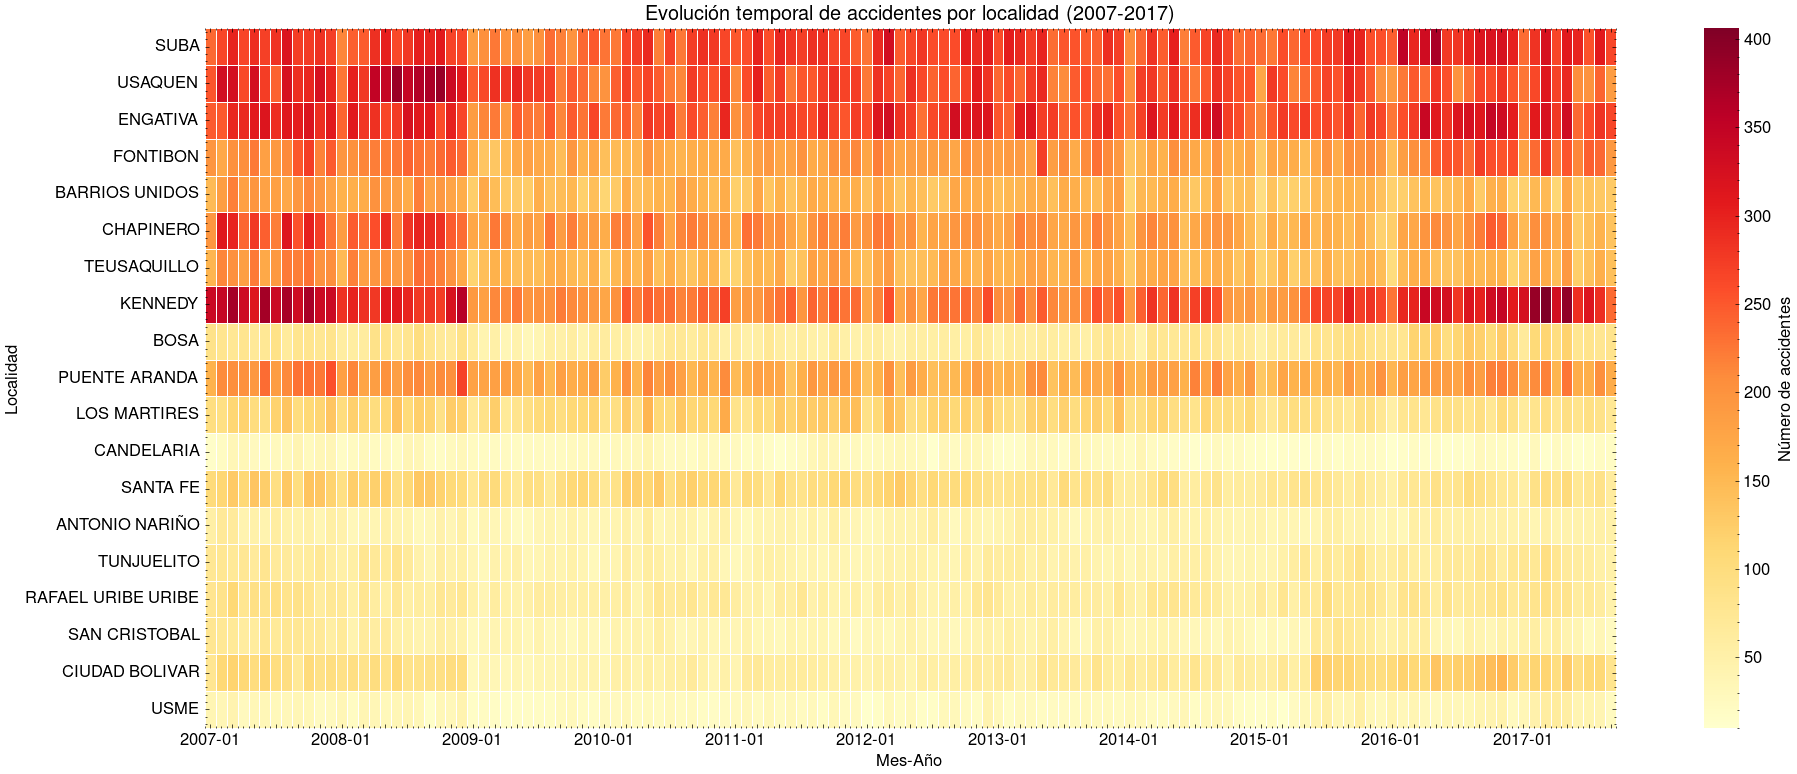

In [171]:
plot_localities_timeline_heatmap(resample_month_df, "latitude", ascending=False)

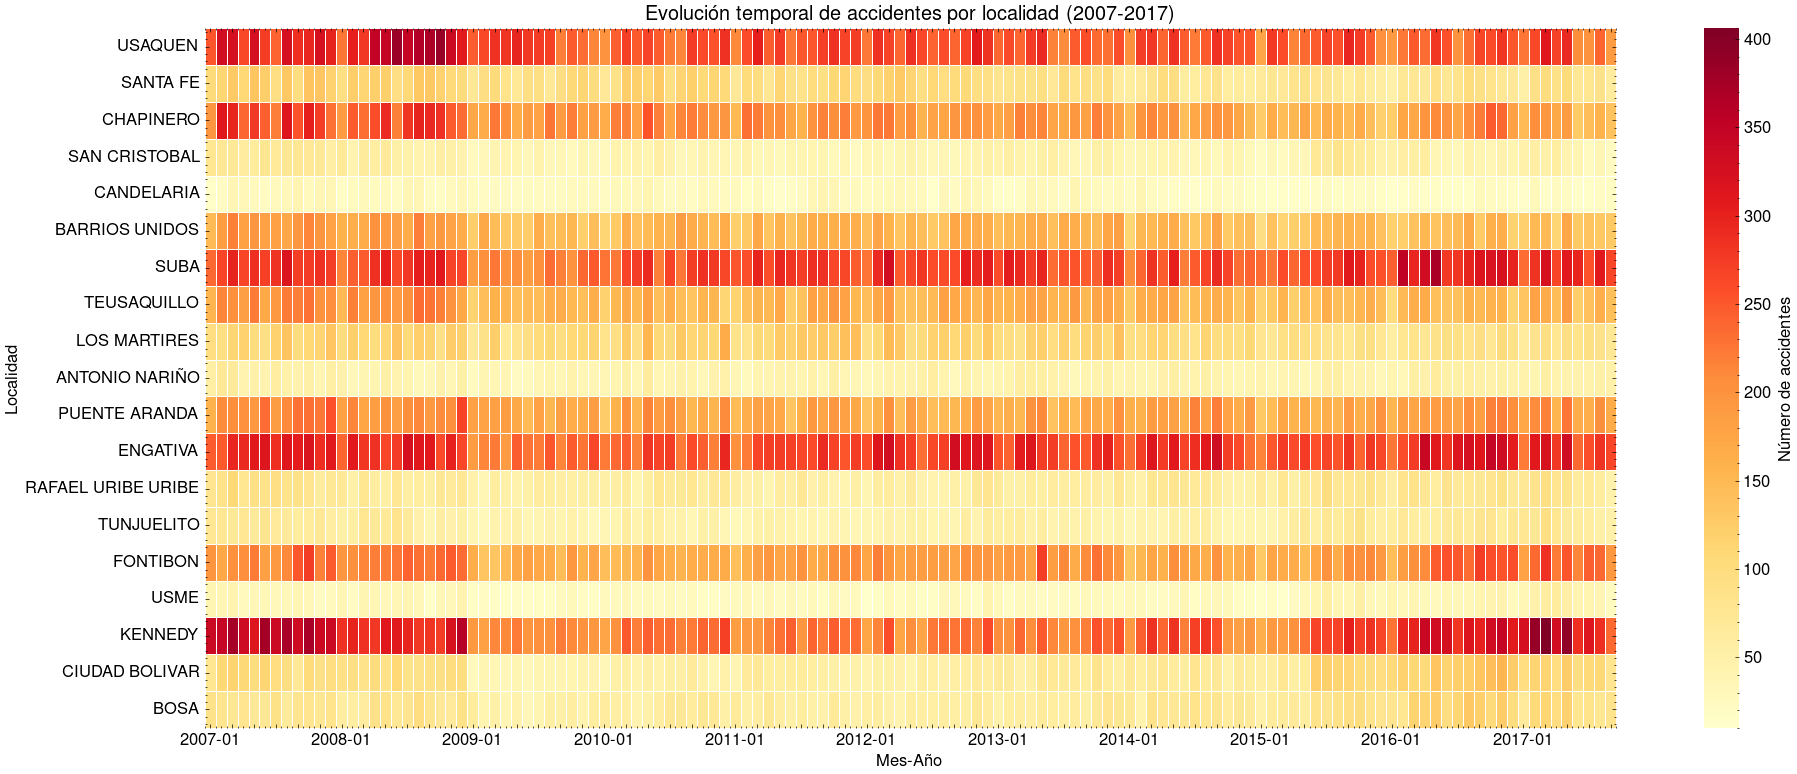

In [172]:
plot_localities_timeline_heatmap(resample_month_df, "longitude", ascending=False)

## For each locality

In [5]:
resample_day_df = resample_data(freq="D", multi_index=True)
scale = resample_day_df["LOCALIDAD"].max().max()
resample_day_df

TOTAL_ACCIDENTES    GRAVEDAD                         CLASE  \
                                  CON HERIDOS SOLO DANOS CON MUERTOS CHOQUE   
FECHA_OCURRENCIA                                                              
2007-01-01                     50          34         16           0     30   
2007-01-02                     71          34         37           0     52   
2007-01-03                     76          33         41           2     49   
2007-01-04                     81          27         54           0     67   
2007-01-05                     70          27         41           2     55   
...                           ...         ...        ...         ...    ...   
2017-09-25                     45          11         34           0     40   
2017-09-26                     63          19         44           0     58   
2017-09-27                     71          26         45           0     60   
2017-09-28                     66          26         40           0     54   
2017-09-29                     22           9         13           0     17   

                                                                        ...  \
                 ATROPELLO VOLCAMIENTO OTRO CAIDA DE OCUPANTE INCENDIO  ...   
FECHA_OCURRENCIA                                                        ...   
2007-01-01              12           4    3                 1        0  ...   
2007-01-02               8           9    1                 1        0  ...   
2007-01-03              10           9    6                 2        0  ...   
2007-01-04               4           4    4                 2        0  ...   
2007-01-05               8           2    4                 1        0  ...   
...                    ...         ...  ...               ...      ...  ...   
2017-09-25               4           0    0                 1        0  ...   
2017-09-26               4           0    0                 1        0  ...   
2017-09-27               6           2    0                 3        0  ...   
2017-09-28               9           1    0                 2        0  ...   
2017-09-29               3           2    0                 0        0  ...   

                 LOCALIDAD                        DIA_SEMANA_OCURRENCIA  \
                  SANTA FE CIUDAD BOLIVAR USAQUEN                 Lunes   
FECHA_OCURRENCIA                                                          
2007-01-01               0              0       0                    50   
2007-01-02               2              1       1                     0   
2007-01-03               3              1       5                     0   
2007-01-04               4              3       5                     0   
2007-01-05               3              3       5                     0   
...                    ...            ...     ...                   ...   
2017-09-25               0              0       5                    45   
2017-09-26               2              1       6                     0   
2017-09-27               3              1       7                     0   
2017-09-28               2              4       4                     0   
2017-09-29               0              1       2                     0   

                                                                 
                 Martes Miercoles Jueves Viernes Sábado Domingo  
FECHA_OCURRENCIA                                                 
2007-01-01            0         0      0       0      0       0  
2007-01-02           71         0      0       0      0       0  
2007-01-03            0        76      0       0      0       0  
2007-01-04            0         0     81       0      0       0  
2007-01-05            0         0      0      70      0       0  
...                 ...       ...    ...     ...    ...     ...  
2017-09-25            0         0      0       0      0       0  
2017-09-26           63         0      0       0      0       0  
2017-09-27            0   

In [11]:
def plot_locality_heatmap(
    df: pd.DataFrame,
    locality: str,
    show: bool = True,
    scale: Optional[int | float] = None,
    **kwargs,
) -> None:
    """Plot a heatmap for a specific locality."""
    if locality not in localities_cols:
        raise ValueError(f"Locality '{locality}' not found in the data.")

    if scale is not None and "vmax" not in kwargs and "vmin" not in kwargs:
        kwargs["vmax"] = scale
        kwargs["vmin"] = 0

    savepath = HEATMAPS_TIMELINES_FIGURES_DIR / (f"scaled_{scale}" if scale else "unscaled")
    savepath.mkdir(parents=True, exist_ok=True)

    fig, _ = calplot.calplot(df["LOCALIDAD"][locality], **kwargs)
    fig.savefig(savepath / f"{locality.lower().replace(' ', '_')}_daily.pdf")

    if show:
        plt.show()
    else:
        plt.close()

In [12]:
for locality in localities_cols:
    for scale_i in [None, scale]:
        plot_locality_heatmap(resample_day_df, locality, show=False, scale=scale_i)